# Structures de données 4 : les arbres

Les listes, les piles et les files sont des structures linéaires. La structure d'un arbre ou d'un graphe est une structure **arborescente** ou **d'arborescence**. Ce sont des structures non linéaires et hiérarchisée.  
On trouve des arbres dans des domaines divers : arbres généalogiques, organigramme d'une société...  

<img src="arbre_Genealogique1.png" width=300 height=300 />

Le sommaire d'un livre peut être représenté sous forme d'un arbre avec les différents chapitres et sections.  
L'oganisation des différents fichiers stockés dans un ordinateur :  

<img src="arbre_fichiers.png" width=500 height=500 />

Notez que la représentation de l’arbre est inversé, le
tronc tout en haut et les branches partant vers le bas... C’est souvent la tradition en informatique.  
Mais vous avez aussi vu des arbres en mathématiques. Par exemple, si on vous
décrit une situation où une urne contient deux boules rouges et trois boules bleues, et qu’on vous demande de calculer la probabilité de tirer deux boules de couleurs différentes, si on ne fait pas de remise, alors vous savez qu’une méthode de résolution consiste à utiliser un arbre de probabilités :  

<img src="arbre_probabilite.png" width=300 height=300 />

**Définition** : 
Un **arbre** est défini par divers éléments :  
* des noeuds;
* des racines;
* des feuilles;
* des branches.  
On peut aussi le définir sur le modèle des liens de parenté avec des enfants et des parents, des descendants, des ancètres, des frères.  
Les branches permettent d'aller de la racine jusqu'à chaque feuille.
On peut aussi parler d'un arbre de manière récursive : soit l'arbre est vide, soit il est composé d'une racine et de sous-arbres. Ces sous-arbres sont aussi des arbres.  
Une autre façon de présenter un arbre est de dire qu'il est composé de noeuds et que chaque noeud, excepté le noeud racine n'a qu'un seul parent ou un seul père. Un noeud qui a un père p est un enfant de p ou un fils de p. Une feuille est un noeud qui n'a pas d'enfant (ou de fils).  

<img src="arbre_organisation.png" width=300 height=300 />

**Définition** : 
Un **arbre binaire** est un arbre pour lequel chaque père a au plus deux fils.  
Donc, soit l'arbre vide, soit il est composé d'une racine, d'un sous-arbre gauche et d'un sous-arbre droit, et ces deux sous-arbres sont des arbres binaires.

En Python, on peut utiliser la structure de liste :  
* une liste vide pour un arbre vide;
* une liste contenant trois éléments,
> - la valeur ou la clé de la racine;  
> - le sous-arbre gauche;  
> - le sous-arbre droit. 

Il est nécéssaire de définir des fonctions pour :  
* créer un arbre vide ou un arbre dont la racine est donné;
* savoir si un arbre est vide ou pas;
* obtenir le sous-arbre gauche ou le sous-arbre droit à partir d'une racine;
* insérer un noeud.

Voici un exemple d'arbres binaires :  
<img src="arbre_bin1.png" width=400 height=400 />

Cet arbre suit la règle suivante, appliquée récursivement:  
> Si la valeur à insérer est inférieure à la valeur de la racine, on l'insère dans le sous-arbre gauche, sinon on l'insère dans le sous-arbre droit.   

**Exercice n°1**
Vérifier que l'arbre précédent vérifie bien cette règle.

Voici une implémentation d'arbre binaire en Python:

In [1]:
def creer_arbre(r):
    if r:
        return [r,[],[]]
    else:
        return []

def arbre_vide(a):
    return a == []

def fils_gauche(a):
    if not arbre_vide(a):
        return a[1]

def fils_droit(a):
    if not arbre_vide(a):
        return a[2]

def insere(a, val):
    if arbre_vide(a):
        a.append(val)
        a.append([])
        a.append([])
    elif val <= a[0]:
        insere(a[1],val)
    else:
        insere(a[2],val)

Test des fonctions :

In [2]:
a = creer_arbre(12)

In [3]:
arbre_vide(a)

False

In [4]:
a

[12, [], []]

In [5]:
insere(a,15)
insere(a,14)
insere(a,8)
insere(a,17)

In [6]:
a

[12, [8, [], []], [15, [14, [], []], [17, [], []]]]

dessiner l'arbre

<img src="g_dessinel_arbre.png" width=400 height=400 />

### Notion de hauteur et de profondeur  
On compte le nombre de noeuds en suivant une branche de la racine à la feuille.    
un noeud de niveau $k$ est le fils d'un noeud de niveau $k-1$. $k$ est la profondeur du noeud de niveau $k$.   
La **hauteur** d'un arbre est le nombre de niveaux. Sachant que la racine a un niveau 0, la **hauteur** est aussi le plus grand nombre de noeud en comptant la racine jusqu'à la feuille. On dit aussi que la **hauteur** d'un arbre est la profondeur maximale de cet arbre.  
On dit qu'un arbre est **complet**, lorsque chaque père, hormis les feuilles, ont exactement deux fils et que les branches issues de la racine ont la même longueur.  
Si h est la hauteur d'un arbre complet, alors le nombre de feuilles est égal à $2^{h}$ et le nombre de noeuds est $2^{h+1}-1$.  
Exemple : 
<img src="exemple_arbre_binaire.png" width=400 height=400 />

Cet arbre est un arbre complet, d'une hauteur égale à 3.
Le nombre de feuilles est égal à $2^2$, soit 4 feuilles.  
Le nombre de noeuds est égal à $2^0+2^1+2^2=2^3-1$, soit 7 noeuds.  
On peut définir un arbre complet par une simple liste :

In [9]:
arbre = [15,12,17,11,14,16,21]

Dans ce cas, les 2 fils du noeud d'indice $i$ se trouvent aux indices $2i+1$ et $2i+2$.

### Un arbre binaire de recherche  
Un **arbre binaire de recherche** est un arbre binaire dont:  
* chaque noeud a au plus deux enfants, soit un sous-arbre de gauche et un sous-arbre de droite;  
* Les enfants à gauche d'un noeud ont des valeurs inférieures à celle du noeud et les enfants à droite d'un noeud ont des valeurs supérieures à celles du noeud.  
Les valeurs sont donc ordonnées dans l'arbre, en les supposant toutes distinctes.  
L'arbre représenté précédement est un arbre de recherche.

**Exercice n°2**  
Dessiner un arbre de recherche contenant les valeurs 11, 13, 14, 15, 17, 18 et 19 satisfaisant la condition donnée dans chacun des deux cas:  
* Dans le 1er cas, la hauteur de l'arbre est 2.
  
* Dans le 2ème cas, l'arbre ressemble à l'arbre ci-dessous:  
<img src="exo2_arbre_binaire.png" width=150 height=200 />
 
**Exercice n°3**   

Lesquels des arbres suivants sont des arbres binaires de recherche et pourquoi ?

<img src="exo3_arbre_binaire.png" width=200 height=100 />


1) 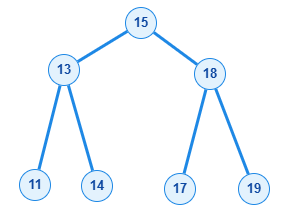
2) 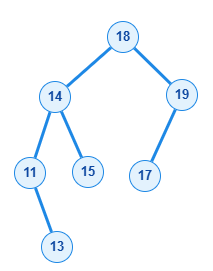

On choisit d'implémenter un arbre binaire de recherche à l'aide de la structure d'une classe.  
On crée la classe Noeud avec quatre attributs : une valeur, un parent, deux enfants que l'on appelera enfant_gauche et enfant_droit. 
Compléter le programme suivant :

In [2]:
class Noeud:
    def __init__(self, valeur):
        self.valeur = valeur
        self.enfant_gauche = None
        self.enfant_droit = None
        self.parent = None
        
    def __str__(self):
        return str(self.valeur)

Les principales opérations à effectuer sont l'insertion et la suppression d'un noeud, ainsi que la recherche d'une valeur. On peut aussi chercher un minimum, un maximum, un prédécesseur et un successeur. On se limitera à la première. Nous reviendront dans un autre chapitre sur les autres opérations.  
Pour implémenter l'ajout d'un noeud : 
* on compare sa valeur avec celle de la racine, puis avec celle de chaque noeud rencontré.
* si cette valeur est inférieure, on continue en descendant à gauche,
* sinon en descendant à droite.
* le dernier noeud rencontré est le parent du nouveau noeud.

In [134]:
class Noeud:
    def __init__(self, valeur):
        self.valeur = valeur
        self.enfant_gauche = None
        self.enfant_droit = None
        self.parent = None
        
    def __str__(self):
        return str(self.valeur)
    
    def ajoute(self, valeur):
        if valeur < self.valeur:
            if self.enfant_gauche is None:
                self.enfant_gauche = Noeud(valeur)
                self.enfant_gauche.parent = self
            else:
                self.enfant_gauche.ajoute(valeur)
        elif valeur > self.valeur:
            if self.enfant_droit is None:
                self.enfant_droit = Noeud(valeur)
                self.enfant_droit.parent = self
            else:
                self.enfant_droit.ajoute(valeur)

Dans la classe noeud

	méthode ajoute une valeur v dans l'arbre:
		si la valeur v est inférieure à la valeur v du noeud de l'arbre:
			si l'enfant gauche du noeud de l'arbre est vide:
				l'enfant gauche du noeud de l'arbre est le noeud de valeur v
				le parent de l'enfant gauche de l'arbre est le noeud
			sinon:
				ajoute la valeur v au noeud de l'enfant gauche
		sinon si la valeur v est supérieure à la valeur v du noeud de l'arbre:
			si l'enfant droit du noeud de l'arbre est vide:
				l'enfant droit du noeud de l'arbre est le noeud de valeur v
				le parent de l'enfant droit de l'arbre est le noeud
			sinon:
				ajoute la valeur v au noeud de l'enfant droit

Tester votre programme :

In [135]:
# On crée l'arbre
arbre = Noeud(17)

In [136]:
print(arbre)

17


In [137]:
# On ajoute des noeuds
arbre.ajoute(10)
arbre.ajoute(23)

In [138]:
print(arbre.enfant_droit)

23


In [139]:
print(arbre.enfant_gauche)

10


In [140]:
arbre.ajoute(12)

In [141]:
print(arbre.enfant_gauche.enfant_droit)

12
